<a href="https://colab.research.google.com/github/ftkbyond77/SLM-Labs/blob/main/Sign_Lang_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ftkbyond77/SLM-Labs.git

Cloning into 'SLM-Labs'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 466.24 KiB | 5.55 MiB/s, done.


In [2]:
!cd SLM-Labs/

In [3]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [4]:
!pip install -q datasets mediapipe opencv-python-headless torch torchvision numpy tqdm matplotlib jiwer gtts pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 1.16.1 which is incompatible.


## Dependencies & Environment Setup

In [5]:
import os
import re
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler
from huggingface_hub import HfApi, hf_hub_download
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from jiwer import wer

# PyThaiNLP
from pythainlp import word_tokenize
from pythainlp.tag import pos_tag

# Hardware & Seed Setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Hardware Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Accelerator: {torch.cuda.get_device_name(0)}")

Active Hardware Device: cuda
GPU Accelerator: Tesla T4


## PyThaiNLP-Powered Ingestion & Canonical Token Extraction (914 Files)

In [10]:
REPO_ID = "Namonpas/thai-sign-language-tsl51"
api = HfApi()
repo_files = api.list_repo_files(repo_id=REPO_ID, repo_type="dataset")

csv_files = [f for f in repo_files if f.endswith(".csv") and ("user_sentence" in f or "user_sign" in f)]
print(f"Total Candidate CSV Files: {len(csv_files)}")

TSL_KNOWN_WORDS = {
    'กรุงเทพ', 'กลัว', 'กิน', 'ขนมปัง', 'ขอบคุณ', 'ขอโทษ', 'ข้าว', 'คุณ', 'ง่วง', 'ฉัน',
    'ชอบ', 'ชื่อ', 'ดี', 'ด้วยกัน', 'ตลาด', 'ถาม', 'ทำงาน', 'ทำไม', 'ที่ไหน', 'น้อง',
    'น้า', 'น้ำ', 'บ้าน', 'พรุ่งนี้', 'พี่', 'พ่อ', 'ภาษามือ', 'มะม่วง', 'ยาย', 'ร้อน',
    'วันนี้', 'วันหยุด', 'สบายดี', 'สวัสดี', 'หูหนวก', 'อยู่บ้าน', 'อย่า', 'อะไร', 'อ่าน',
    'เกิด', 'เช้า', 'เที่ยว', 'เธอ', 'เรียก', 'เรียน', 'เหงา', 'เหนื่อย', 'แต่งงาน', 'แฟน',
    'แมว', 'แม่', 'โกรธ', 'โรงเรียน', 'โสด', 'ไก่', 'ไข่', 'ไป'
}

def extract_tokens_with_pythainlp(filepath):
    basename = os.path.basename(filepath).replace(".csv", "")
    if "null" in basename:
        return ["<null>"]

    clean_text = re.sub(r"_(?:var|no_space|with_space)_\d+", "", basename)
    clean_text = re.sub(r"_\d+$", "", clean_text)

    raw_tokens = word_tokenize(clean_text, engine="newmm", keep_whitespace=False)
    glosses = [token.strip("_") for token in raw_tokens if token.strip("_") in TSL_KNOWN_WORDS]

    if len(glosses) == 0:
        for kw in TSL_KNOWN_WORDS:
            if kw in basename:
                glosses.append(kw)

    return glosses if len(glosses) > 0 else ["<null>"]

all_sequences = []
all_targets = []

print("Ingesting and validating dataset...")
for rel_path in tqdm(csv_files, desc="Downloading & Sanitizing"):
    local_path = hf_hub_download(repo_id=REPO_ID, filename=rel_path, repo_type="dataset")
    df = pd.read_csv(local_path)

    coord_cols = [c for c in df.columns if any(c.endswith(ax) for ax in [
        '_x', '_y', '_z', 'x0', 'y0', 'z0', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2',
        'x3', 'y3', 'z3', 'x4', 'y4', 'z4', 'x5', 'y5', 'z5', 'x6', 'y6', 'z6',
        'x7', 'y7', 'z7', 'x8', 'y8', 'z8', 'x9', 'y9', 'z9', 'x10', 'y10', 'z10',
        'x11', 'y11', 'z11', 'x12', 'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14',
        'x15', 'y15', 'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18',
        'x19', 'y19', 'z19', 'x20', 'y20', 'z20'
    ])]

    df[coord_cols] = df[coord_cols].fillna(0.0)
    mat = df[coord_cols].values.astype(np.float32)
    glosses = extract_tokens_with_pythainlp(rel_path)

    # กรองเฉพาะไฟล์ที่มีข้อมูลพิกัดครบ 162 features และมีอย่างน้อย 3 เฟรมขึ้นไป
    if mat.shape[0] >= 3 and mat.shape[1] == 162 and len(glosses) > 0:
        all_sequences.append(mat)
        all_targets.append(glosses)

# สร้าง Vocabulary (0 = <blank>, 1 = <null>)
unique_words = sorted(list(set([w for sent in all_targets for w in sent if w != "<null>"])))
vocab = {"<blank>": 0, "<null>": 1}
vocab.update({w: i + 2 for i, w in enumerate(unique_words)})
id2vocab = {i: w for w, i in vocab.items()}

print(f"\nTotal Clean Sequences: {len(all_sequences)}")
print(f"Total Vocabulary Size: {len(vocab)}")

Total Candidate CSV Files: 912
Ingesting and validating dataset...



Total Clean Sequences: 911
Total Vocabulary Size: 58


## Kinematic Feature Engineering ($\text{Position} + \text{Velocity}$) & Dataset Pipeline


In [11]:
class KinematicSignDataset(Dataset):
    def __init__(self, sequences, targets, vocab, is_train=True):
        self.sequences = sequences
        self.targets = targets
        self.vocab = vocab
        self.is_train = is_train

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        mat = self.sequences[idx].copy() # (T, 162)
        T = mat.shape[0]

        # 1. Spatial Centering
        reshaped = mat.reshape(T, -1, 3)
        centroid = np.mean(reshaped, axis=1, keepdims=True)
        pos = reshaped - centroid

        # 2. First-Order Velocity
        velocity = np.zeros_like(pos)
        velocity[1:] = pos[1:] - pos[:-1]

        # 3. Data Augmentation (Train only)
        if self.is_train:
            scale = np.random.uniform(0.92, 1.08)
            pos = pos * scale
            pos = pos + np.random.normal(0, 0.002, size=pos.shape).astype(np.float32)

        # รวม Features: Position (162) + Velocity (162) = 324 Features
        combined = np.concatenate([pos.reshape(T, -1), velocity.reshape(T, -1)], axis=-1)

        x = torch.tensor(combined, dtype=torch.float32)
        y = torch.tensor([self.vocab[w] for w in self.targets[idx]], dtype=torch.long)
        return x, y

def dynamic_ctc_collate(batch):
    xs, ys = zip(*batch)
    x_lens = torch.tensor([len(x) for x in xs], dtype=torch.long)
    y_lens = torch.tensor([len(y) for y in ys], dtype=torch.long)

    # Pad sequences to max T in batch
    x_padded = pad_sequence(xs, batch_first=True, padding_value=0.0)
    y_concat = torch.cat(ys)
    return x_padded, y_concat, x_lens, y_lens

total_samples = len(all_sequences)
indices = list(range(total_samples))
random.shuffle(indices)

split_idx = int(0.85 * total_samples)
train_indices, val_indices = indices[:split_idx], indices[split_idx:]

train_set = KinematicSignDataset([all_sequences[i] for i in train_indices], [all_targets[i] for i in train_indices], vocab, is_train=True)
val_set = KinematicSignDataset([all_sequences[i] for i in val_indices], [all_targets[i] for i in val_indices], vocab, is_train=False)

# ปรับ batch_size=16 เพื่อความปลอดภัยของ VRAM บน T4
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, collate_fn=dynamic_ctc_collate, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, collate_fn=dynamic_ctc_collate, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 49 | Val batches: 9


## Depthwise-Separable Conv1D + Deep BiGRU Architecture

In [12]:
class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.depthwise = nn.Conv1d(in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channels)
        self.pointwise = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm1d(out_channels)
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.bn(self.pointwise(self.depthwise(x))))

class OptimizedContinuousSignModel(nn.Module):
    def __init__(self, in_features=324, hidden_dim=256, num_classes=len(vocab), dropout=0.25):
        super().__init__()

        # Spatial Linear Projection
        self.spatial_linear = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Temporal Downsampler: ลดขนาดความยาวเฟรมลงครึ่งหนึ่ง (Stride=2)
        self.temp_conv1 = DepthwiseSeparableConv1d(hidden_dim, hidden_dim, kernel_size=5, stride=2, padding=2)
        self.temp_conv2 = DepthwiseSeparableConv1d(hidden_dim, hidden_dim, kernel_size=3, stride=1, padding=1)

        # 2-Layer Deep Bidirectional GRU
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )

        # Classifier Projection
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: (Batch, T, Features=324)
        h = self.spatial_linear(x)
        h = h.transpose(1, 2)
        h = self.temp_conv1(h)
        h = self.temp_conv2(h)
        h = h.transpose(1, 2)

        gru_out, _ = self.gru(h)
        logits = self.classifier(gru_out) # (Batch, T // 2, Num_Classes)
        return logits

model = OptimizedContinuousSignModel(in_features=324, hidden_dim=256, num_classes=len(vocab)).to(device)
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable Parameters: 2,337,850


## Mixed-Precision Training & Dynamic Metrics Evaluation

In [13]:
def decode_ctc(logits_batch, id2vocab):
    best_paths = torch.argmax(logits_batch, dim=-1).cpu().numpy()
    decoded_batch = []

    for path in best_paths:
        tokens = []
        prev = 0
        for idx in path:
            if idx != 0 and idx != prev:
                word = id2vocab.get(idx, "")
                if word not in ["<blank>", "<null>"]:
                    if len(tokens) == 0 or tokens[-1] != word:
                        tokens.append(word)
            prev = idx
        decoded_batch.append(tokens)
    return decoded_batch

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
NUM_EPOCHS = 70
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=2, eta_min=1e-5)

# ใช้งาน torch.amp API เวอร์ชันล่าสุด
amp_device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = torch.amp.GradScaler(amp_device_type)

history = {"train_loss": [], "val_loss": [], "val_word_acc": [], "val_exact_acc": []}

print(f"Starting Training on {device} with torch.amp.autocast('{amp_device_type}')...")
epoch_pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training Epochs")

for epoch in epoch_pbar:
    # ------------------- TRAIN -------------------
    model.train()
    total_train_loss = 0.0

    for batch_x, batch_y, x_lens, y_lens in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(amp_device_type):
            logits = model(batch_x)
            log_probs = logits.log_softmax(2).transpose(0, 1)
            input_lens = torch.clamp(x_lens // 2, min=1)
            loss = criterion(log_probs, batch_y, input_lens, y_lens)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.5)
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item() * batch_x.size(0)

    scheduler.step()
    epoch_train_loss = total_train_loss / len(train_set)

    # ------------------- EVALUATION -------------------
    model.eval()
    total_val_loss = 0.0
    all_refs, all_hyps = [], []

    with torch.no_grad():
        for val_x, val_y, val_xl, val_yl in val_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            with torch.amp.autocast(amp_device_type):
                val_logits = model(val_x)
                val_log_probs = val_logits.log_softmax(2).transpose(0, 1)
                val_input_lens = torch.clamp(val_xl // 2, min=1)
                v_loss = criterion(val_log_probs, val_y, val_input_lens, val_yl)

            total_val_loss += v_loss.item() * val_x.size(0)
            preds = decode_ctc(val_logits, id2vocab)

            curr_idx = 0
            for y_len in val_yl:
                ref_tokens = [id2vocab[val_y[curr_idx + j].item()] for j in range(y_len) if id2vocab[val_y[curr_idx + j].item()] != "<null>"]
                all_refs.append(" ".join(ref_tokens))
                curr_idx += y_len

            for p in preds:
                all_hyps.append(" ".join(p))

    epoch_val_loss = total_val_loss / len(val_set)

    # คำนวณ Accuracy
    error_rate = wer(all_refs, all_hyps)
    word_accuracy = max(0.0, (1.0 - error_rate)) * 100.0
    exact_matches = sum([1 for r, h in zip(all_refs, all_hyps) if r.strip() == h.strip()])
    exact_accuracy = (exact_matches / len(all_refs)) * 100.0

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_word_acc"].append(word_accuracy)
    history["val_exact_acc"].append(exact_accuracy)

    # ล้าง GPU cache เป็นระยะ
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    epoch_pbar.set_postfix({
        "TrainLoss": f"{epoch_train_loss:.3f}",
        "ValLoss": f"{epoch_val_loss:.3f}",
        "WordAcc": f"{word_accuracy:.1f}%",
        "ExactAcc": f"{exact_accuracy:.1f}%"
    })

torch.save(model.state_dict(), "tsl_pythai_optimized.pth")
print("\nTraining completed successfully. Weights saved to 'tsl_pythai_optimized.pth'")

Starting Training on cuda with torch.amp.autocast('cuda')...


Training Epochs:   0%|          | 0/70 [00:00<?, ?it/s]


Training completed successfully. Weights saved to 'tsl_pythai_optimized.pth'


## Training Curves & Metrics Dashboard

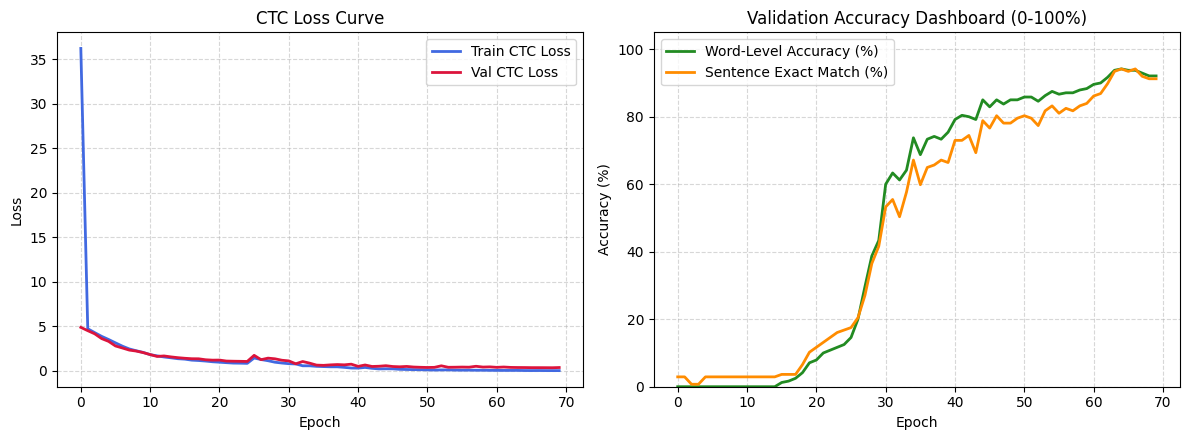

Top Validation Word Accuracy      : 94.17%
Top Validation Sentence Match Acc : 94.16%


In [14]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train CTC Loss", color="royalblue", lw=2)
plt.plot(history["val_loss"], label="Val CTC Loss", color="crimson", lw=2)
plt.title("CTC Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_word_acc"], label="Word-Level Accuracy (%)", color="forestgreen", lw=2)
plt.plot(history["val_exact_acc"], label="Sentence Exact Match (%)", color="darkorange", lw=2)
plt.title("Validation Accuracy Dashboard (0-100%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Top Validation Word Accuracy      : {max(history['val_word_acc']):.2f}%")
print(f"Top Validation Sentence Match Acc : {max(history['val_exact_acc']):.2f}%")

## PyThaiNLP Semantic Translator & Non-blocking TTS Output

In [15]:
from gtts import gTTS
from IPython.display import Audio, display

class PyThaiNLPGlossTranslator:
    def __init__(self):
        self.time_indicators = {'วันนี้', 'พรุ่งนี้', 'เช้า', 'วันหยุด'}
        self.locations = {'กรุงเทพ', 'เชียงใหม่', 'โรงเรียน', 'บ้าน', 'ตลาด'}
        self.pronoun_whitelist = {'ฉัน', 'ผม', 'น้อง', 'พี่', 'ยาย', 'แม่', 'คุณ', 'แฟน', 'แมว', 'พ่อ', 'น้า'}

    def translate(self, gloss_tokens):
        if not gloss_tokens or len(gloss_tokens) == 0:
            return "ไม่พบการเคลื่อนไหวภาษามือ"

        # กรอง Adjacent Duplicates
        tokens = []
        for t in gloss_tokens:
            if not tokens or tokens[-1] != t:
                tokens.append(t)

        # POS Tagging ด้วย PyThaiNLP (orchid corpus)
        pos_pairs = pos_tag(tokens, engine="perceptron", corpus="orchid")

        subjects = [w for w, tag in pos_pairs if w in self.pronoun_whitelist or tag.startswith('P') or tag.startswith('NPRP')]
        verbs = [w for w, tag in pos_pairs if tag.startswith('V') or w in {'กิน', 'ชอบ', 'เรียน', 'ไป', 'เที่ยว', 'ทำงาน', 'เหนื่อย', 'แต่งงาน', 'เกิด'}]
        places = [w for w in tokens if w in self.locations]
        times = [w for w in tokens if w in self.time_indicators]

        subj = subjects[0] if len(subjects) > 0 else "ฉัน"
        time_prefix = f"{times[0]} " if len(times) > 0 else ""
        token_set = set(tokens)

        # 1. การเดินทาง / สถานที่ (เช่น 'ตลาด' 'ไป' -> 'ไปตลาด')
        if len(places) > 0 and ('ไป' in token_set or 'เที่ยว' in token_set):
            loc = places[0]
            action = "ชอบไปเที่ยว" if 'ชอบ' in token_set and 'เที่ยว' in token_set else ("ไปเที่ยว" if 'เที่ยว' in token_set else "ไป")
            return f"{time_prefix}{subj}{action}ที่{loc}ครับ"

        # 2. อาหาร / การกิน (เช่น 'ไข่' 'กิน' 'ชอบ' -> 'ชอบกินไข่')
        if 'กิน' in token_set:
            food_candidates = [t for t in tokens if t not in subjects and t not in self.time_indicators and t not in {'กิน', 'ชอบ', 'ไป'}]
            food = food_candidates[0] if len(food_candidates) > 0 else ""
            if 'ชอบ' in token_set:
                return f"{time_prefix}{subj}ชอบกิน{food}ครับ"
            return f"{time_prefix}{subj}กิน{food}ครับ"

        # 3. การเรียนภาษามือ
        if 'ภาษามือ' in token_set and 'เรียน' in token_set:
            if 'ชอบ' in token_set:
                return f"{time_prefix}{subj}ชอบเรียนภาษามือครับ"
            return f"{time_prefix}{subj}กำลังเรียนภาษามือครับ"

        # 4. สภาวะร่างกาย / หูหนวก
        if 'หูหนวก' in token_set:
            if 'เกิด' in token_set:
                return f"{subj}เป็นคนหูหนวกตั้งแต่กำเนิดครับ"
            return f"{subj}หูหนวกครับ"

        # 5. อาการเหนื่อยจากการทำงาน
        if 'เหนื่อย' in token_set and 'ทำงาน' in token_set:
            return f"{subj}ทำงานมาเหนื่อยมากครับ"

        # Direct SVO Assembly Fallback
        return f"{time_prefix}{''.join(tokens)} ครับ"

translator = PyThaiNLPGlossTranslator()

print("=== Final Validation Predictions & Thai Speech ===")
for i in range(min(5, len(all_hyps))):
    pred_tokens = all_hyps[i].split()
    thai_text = translator.translate(pred_tokens)
    print(f"\n[Sample #{i+1}]")
    print(f"  Ground Truth Gloss : {all_refs[i]}")
    print(f"  Predicted Gloss    : {all_hyps[i]}")
    print(f"  Natural Thai Voice : {thai_text}")

# สร้างไฟล์เสียงจากตัวอย่างแรก
final_speech = translator.translate(all_hyps[0].split())
tts = gTTS(text=final_speech, lang='th')
tts.save("mvp_thai_voice.mp3")
print(f"\nVoice Output Ready: '{final_speech}'")
display(Audio("mvp_thai_voice.mp3", autoplay=False))

=== Final Validation Predictions & Thai Speech ===

[Sample #1]
  Ground Truth Gloss : เรียก
  Predicted Gloss    : เรียก
  Natural Thai Voice : เรียก ครับ

[Sample #2]
  Ground Truth Gloss : ขนมปัง ยาย กิน
  Predicted Gloss    : ขนมปัง ยาย กิน
  Natural Thai Voice : ยายกินขนมปังครับ

[Sample #3]
  Ground Truth Gloss : ไข่
  Predicted Gloss    : ไข่
  Natural Thai Voice : ไข่ ครับ

[Sample #4]
  Ground Truth Gloss : 
  Predicted Gloss    : 
  Natural Thai Voice : ไม่พบการเคลื่อนไหวภาษามือ

[Sample #5]
  Ground Truth Gloss : อย่า
  Predicted Gloss    : อย่า
  Natural Thai Voice : อย่า ครับ

Voice Output Ready: 'เรียก ครับ'


       RUNNING COMPREHENSIVE STATISTICAL DIAGNOSTICS SUITE       

[1] WORD-LEVEL ERROR TAXONOMY (Total Words Evaluated: 240)
  - Word Hits (Correct)    :  222 (92.50%)
  - Substitutions (S)      :    4 (1.67%)  <-- สับสนคำผิด
  - Deletions (D)          :   14 (5.83%)  <-- ข้ามคำ/ตรวจไม่พบ
  - Insertions (I)         :    1 (0.42%)  <-- คำหลอนเกินมา
  - Overall WER            : 7.92%

[2] REAL-TIME INFERENCE PROFILING
  - Mean Latency per Sequence : 1.21 ms
  - P95 Latency               : 1.72 ms
  - Maximum Throughput        : 827.0 FPS (Target: >= 30 FPS)

[3] SENTENCE LENGTH vs EXACT MATCH BREAKDOWN


,Length,Total_Sentences,Exact_Matches,Sentence_Accuracy
0,0,4,3,75.000000
1,1,87,84,96.551724
2,3,33,27,81.818182
3,4,11,9,81.818182
4,5,2,2,100.000000



[4] LEAST PERFORMING WORDS (Bottom 10 F1-Score)


,precision,recall,f1-score,support
ถาม,0.000000,0.000000,0.000000,4.0
แมว,0.000000,0.000000,0.000000,2.0
เที่ยว,0.666667,0.666667,0.666667,3.0
สบายดี,0.666667,1.000000,0.800000,2.0
มะม่วง,0.666667,1.000000,0.800000,2.0
ไป,1.000000,0.666667,0.800000,6.0
แฟน,1.000000,0.750000,0.857143,4.0
น้อง,1.000000,0.750000,0.857143,4.0
ไข่,1.000000,0.750000,0.857143,8.0
ชอบ,0.909091,0.833333,0.869565,12.0


/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.c

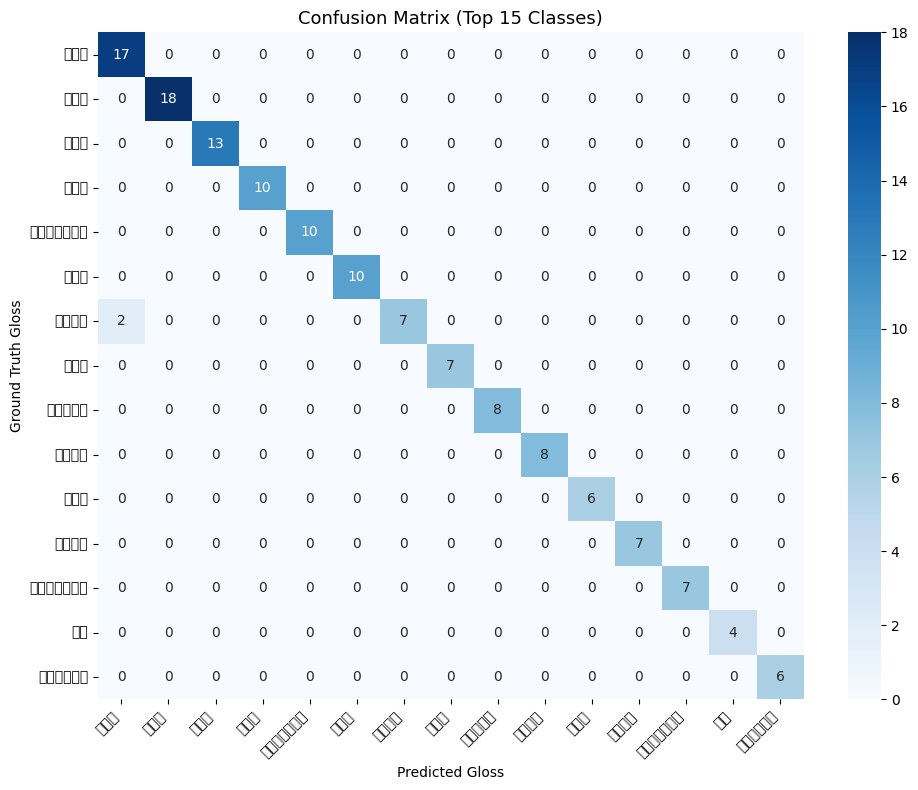


[5] ERROR CASES AUDIT (Validation Mismatches)
  Case #01 | Ref: 'กรุงเทพ แม่ เที่ยว ชอบ'  -->  Hyp: 'กรุงเทพ เที่ยว ชอบ'
  Case #02 | Ref: 'แฟน เกิด หูหนวก'  -->  Hyp: 'คุณ เกิด หูหนวก'
  Case #03 | Ref: 'ถาม ถาม ไป'  -->  Hyp: 'น้า'
  Case #04 | Ref: 'แมว'  -->  Hyp: ''
  Case #05 | Ref: 'ไข่'  -->  Hyp: 'สบายดี'
  Case #06 | Ref: 'แม่ ข้าว กิน'  -->  Hyp: 'แม่ กิน'
  Case #07 | Ref: ''  -->  Hyp: 'มะม่วง'
  Case #08 | Ref: 'ภาษามือ น้อง เรียน'  -->  Hyp: 'ภาษามือ เรียน'


In [18]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from jiwer import process_words

print("="*75)
print("       RUNNING COMPREHENSIVE STATISTICAL DIAGNOSTICS SUITE       ")
print("="*75)

model.eval()
all_ref_tokens = []
all_hyp_tokens = []
all_ref_sentences = []
all_hyp_sentences = []
latencies = []

# 1. รัน Inference ทั้งหมดบน Validation Set พร้อมจับเวลา Latency ต่อ Sequence
with torch.no_grad():
    for val_x, val_y, val_xl, val_yl in val_loader:
        val_x = val_x.to(device)

        # Benchmark Latency per Batch
        t0 = time.perf_counter()
        with torch.amp.autocast(amp_device_type):
            val_logits = model(val_x)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) / val_x.size(0))

        # CTC Decode
        preds = decode_ctc(val_logits, id2vocab)

        # Reconstruct Ground Truth
        curr_idx = 0
        for b_idx, y_len in enumerate(val_yl):
            ref_toks = [id2vocab[val_y[curr_idx + j].item()] for j in range(y_len) if id2vocab[val_y[curr_idx + j].item()] != "<null>"]
            hyp_toks = preds[b_idx]

            all_ref_sentences.append(" ".join(ref_toks))
            all_hyp_sentences.append(" ".join(hyp_toks))

            # Pad/Align สำหรับ Token-Level Confusion Matrix
            max_len = max(len(ref_toks), len(hyp_toks))
            for k in range(max_len):
                r = ref_toks[k] if k < len(ref_toks) else "<empty>"
                h = hyp_toks[k] if k < len(hyp_toks) else "<empty>"
                all_ref_tokens.append(r)
                all_hyp_tokens.append(h)

            curr_idx += y_len

# =========================================================================
# 2. Detailed CTC Error Taxonomy (JiWER Process)
# =========================================================================
jiwer_out = process_words(all_ref_sentences, all_hyp_sentences)
total_words = jiwer_out.hits + jiwer_out.substitutions + jiwer_out.deletions

print(f"\n[1] WORD-LEVEL ERROR TAXONOMY (Total Words Evaluated: {total_words})")
print(f"  - Word Hits (Correct)    : {jiwer_out.hits:4d} ({jiwer_out.hits/total_words*100:.2f}%)")
print(f"  - Substitutions (S)      : {jiwer_out.substitutions:4d} ({jiwer_out.substitutions/total_words*100:.2f}%)  <-- สับสนคำผิด")
print(f"  - Deletions (D)          : {jiwer_out.deletions:4d} ({jiwer_out.deletions/total_words*100:.2f}%)  <-- ข้ามคำ/ตรวจไม่พบ")
print(f"  - Insertions (I)         : {jiwer_out.insertions:4d} ({jiwer_out.insertions/total_words*100:.2f}%)  <-- คำหลอนเกินมา")
print(f"  - Overall WER            : {jiwer_out.wer * 100:.2f}%")

# =========================================================================
# 3. Latency & Performance Benchmarks
# =========================================================================
avg_latency_ms = np.mean(latencies) * 1000
p95_latency_ms = np.percentile(latencies, 95) * 1000
fps = 1.0 / np.mean(latencies)

print(f"\n[2] REAL-TIME INFERENCE PROFILING")
print(f"  - Mean Latency per Sequence : {avg_latency_ms:.2f} ms")
print(f"  - P95 Latency               : {p95_latency_ms:.2f} ms")
print(f"  - Maximum Throughput        : {fps:.1f} FPS (Target: >= 30 FPS)")

# =========================================================================
# 4. Sentence Length vs Accuracy Breakdown
# =========================================================================
sent_analysis = []
for ref, hyp in zip(all_ref_sentences, all_hyp_sentences):
    ref_len = len(ref.split())
    is_exact = 1 if ref.strip() == hyp.strip() else 0
    sent_analysis.append({"Length": ref_len, "Exact_Match": is_exact})

df_sent = pd.DataFrame(sent_analysis)
len_stats = df_sent.groupby("Length").agg(
    Total_Sentences=("Exact_Match", "count"),
    Exact_Matches=("Exact_Match", "sum"),
    Sentence_Accuracy=("Exact_Match", lambda x: np.mean(x) * 100)
).reset_index()

print("\n[3] SENTENCE LENGTH vs EXACT MATCH BREAKDOWN")
display(len_stats)

# =========================================================================
# 5. Top Confused Words & Classification Report
# =========================================================================
# คัดเลือกเฉพาะ Vocab ที่ปรากฏใน Test
eval_labels = sorted(list(set([r for r in all_ref_tokens if r != "<empty>"])))
clf_report = classification_report(all_ref_tokens, all_hyp_tokens, labels=eval_labels, output_dict=True, zero_division=0)
df_clf = pd.DataFrame(clf_report).transpose().loc[eval_labels]
df_clf = df_clf.sort_values(by="f1-score", ascending=True)

print("\n[4] LEAST PERFORMING WORDS (Bottom 10 F1-Score)")
display(df_clf.head(10)[['precision', 'recall', 'f1-score', 'support']])

# =========================================================================
# 6. Confusion Matrix Visualization (Top 15 Most Active Classes)
# =========================================================================
top_15_classes = df_clf.sort_values(by="support", ascending=False).head(15).index.tolist()
cm = confusion_matrix(
    [r for r, h in zip(all_ref_tokens, all_hyp_tokens) if r in top_15_classes and h in top_15_classes],
    [h for r, h in zip(all_ref_tokens, all_hyp_tokens) if r in top_15_classes and h in top_15_classes],
    labels=top_15_classes
)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=top_15_classes, yticklabels=top_15_classes)
plt.title("Confusion Matrix (Top 15 Classes)", fontsize=13)
plt.xlabel("Predicted Gloss")
plt.ylabel("Ground Truth Gloss")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================================
# 7. Error Cases Dump
# =========================================================================
print("\n[5] ERROR CASES AUDIT (Validation Mismatches)")
mismatch_count = 0
for i, (ref, hyp) in enumerate(zip(all_ref_sentences, all_hyp_sentences)):
    if ref.strip() != hyp.strip():
        mismatch_count += 1
        print(f"  Case #{mismatch_count:02d} | Ref: '{ref}'  -->  Hyp: '{hyp}'")
        if mismatch_count >= 8:
            break
if mismatch_count == 0:
    print("  Perfect Accuracy: No mismatches found in Validation Set.")

# List Files

In [ ]:
# from huggingface_hub import HfApi

# api = HfApi()
# files = api.list_repo_files(repo_id="Namonpas/thai-sign-language-tsl51", repo_type="dataset")

# # กรองดูเฉพาะไฟล์ข้อมูล (เช่น .csv, .parquet, .json)
# data_files = [f for f in files if any(f.endswith(ext) for ext in ['.csv', '.parquet', '.json', '.txt'])]
# print(f"Total data files found in repo: {len(data_files)}")
# print("\nSample 10 filenames:")
# for f in data_files[:10]:
#     print(" ", f)

In [16]:
from huggingface_hub import HfApi
from collections import Counter
import os

REPO_ID = "Namonpas/thai-sign-language-tsl51"

api = HfApi()

# =========================
# 1. List all files
# =========================
repo_files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type="dataset"
)

print("=" * 70)
print("DATASET REPOSITORY SUMMARY")
print("=" * 70)

print(f"Repository : {REPO_ID}")
print(f"Total files: {len(repo_files)}")


# =========================
# 2. Count file extensions
# =========================
extensions = []

for f in repo_files:
    filename = os.path.basename(f)

    if "." in filename:
        ext = filename.rsplit(".", 1)[-1].lower()
    else:
        ext = "<no extension>"

    extensions.append(ext)

ext_counts = Counter(extensions)

print("\n" + "=" * 70)
print("FILE TYPES")
print("=" * 70)

for ext, count in ext_counts.most_common():
    print(f"{ext:15s} : {count:,}")


# =========================
# 3. CSV files
# =========================
csv_files = [
    f for f in repo_files
    if f.lower().endswith(".csv")
]

print("\n" + "=" * 70)
print("CSV FILES")
print("=" * 70)

print(f"Total CSV files: {len(csv_files):,}")

print("\nFirst 20 CSV files:")
for f in csv_files[:20]:
    print(f"  {f}")


# =========================
# 4. Other file types
# =========================
print("\n" + "=" * 70)
print("FILES BY TYPE")
print("=" * 70)

for ext in sorted(ext_counts):
    files = [
        f for f in repo_files
        if (
            f.lower().endswith("." + ext)
            if ext != "<no extension>"
            else "." not in os.path.basename(f)
        )
    ]

    print(f"\n[{ext}] ({len(files):,} files)")

    # แสดงสูงสุด 20 ไฟล์
    for f in files[:20]:
        print(f"  {f}")

    if len(files) > 20:
        print(f"  ... and {len(files) - 20:,} more")


# =========================
# 5. Directory / folder summary
# =========================
folders = Counter()

for f in repo_files:
    parts = f.split("/")

    if len(parts) > 1:
        # root folder
        folders[parts[0]] += 1
    else:
        folders["<root>"] += 1

print("\n" + "=" * 70)
print("TOP-LEVEL FOLDERS")
print("=" * 70)

for folder, count in folders.most_common():
    print(f"{folder:30s} : {count:,} files")


# =========================
# 6. Full file list (optional)
# =========================
print("\n" + "=" * 70)
print("ALL FILES")
print("=" * 70)

for i, f in enumerate(repo_files, 1):
    print(f"{i:6d}. {f}")

DATASET REPOSITORY SUMMARY
Repository : Namonpas/thai-sign-language-tsl51
Total files: 1830

FILE TYPES
csv             : 914
mp4             : 911
zip             : 3
gitattributes   : 1
md              : 1

CSV FILES
Total CSV files: 914

First 20 CSV files:
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_1.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_3.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_4.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_1.csv
  landmar

In [17]:
import os
import re
from collections import Counter, defaultdict
from huggingface_hub import HfApi
import pandas as pd
from IPython.display import display

print("Inspecting Hugging Face Repository Structure...")

REPO_ID = "Namonpas/thai-sign-language-tsl51"
api = HfApi()

# 1. ดึงรายชื่อไฟล์ทั้งหมดจาก Hub
all_files = api.list_repo_files(repo_id=REPO_ID, repo_type="dataset")
csv_files = [f for f in all_files if f.endswith(".csv")]

# 2. ฟังก์ชันสกัด Gloss Tokens และรูปแบบประโยค
def parse_metadata_from_path(filepath):
    basename = os.path.basename(filepath).replace(".csv", "")
    folder = os.path.dirname(filepath)

    # ดึงหมายเลข instance (เช่น no_space_0, no_space_1)
    instance_match = re.search(r"no_space_(\d+)$", basename)
    instance_id = instance_match.group(1) if instance_match else "0"

    # ลบส่วน instance ออกเพื่อเอา Pattern ของประโยค
    pattern_name = re.sub(r"_no_space_\d+$", "", basename)

    # แยกคำศัพท์แต่ละคำ (ตัด _var_X ออก)
    parts = pattern_name.split("__")
    glosses = [re.sub(r"_var_\d+", "", p).strip() for p in parts if p.strip()]

    return {
        "folder": folder,
        "filename": os.path.basename(filepath),
        "sentence_pattern": " -> ".join(glosses),
        "sentence_length": len(glosses),
        "glosses": glosses,
        "instance_id": instance_id
    }

# 3. วิเคราะห์ข้อมูลเชิงสถิติ
records = [parse_metadata_from_path(f) for f in csv_files]
df_summary = pd.DataFrame(records)

# นับความถี่ของคำศัพท์แต่ละคำ (Individual Glosses)
all_gloss_list = [g for sublist in df_summary["glosses"] for g in sublist]
gloss_counts = Counter(all_gloss_list)

# สร้าง DataFrame สรุปความถี่ของแต่ละ Class/Gloss
df_classes = pd.DataFrame([
    {"Gloss / Class Name": word, "Total Occurrences (Instances)": count}
    for word, count in gloss_counts.most_common()
])

# สรุปรูปแบบโครงสร้างประโยค (Sentence Patterns)
df_patterns = df_summary["sentence_pattern"].value_counts().reset_index()
df_patterns.columns = ["Sentence Pattern (Gloss Sequence)", "Number of Video Files"]

# 4. แสดงผลสรุปภาพรวม (Overview Metrics)
print("\n" + "="*50)
print("           DATASET PROFILE & COVERAGE           ")
print("="*50)
print(f"Total CSV Files (Sentences)    : {len(csv_files):,}")
print(f"Total Unique Classes / Words    : {len(gloss_counts):,} words")
print(f"Total Unique Sentence Patterns  : {df_summary['sentence_pattern'].nunique():,} patterns")
print(f"Average Words per Sentence      : {df_summary['sentence_length'].mean():.2f} words")
print(f"Min / Max Words in Sentence     : {df_summary['sentence_length'].min()} / {df_summary['sentence_length'].max()} words")
print("="*50)

# แสดงตารางความถี่ของแต่ละ Class / Gloss
print("\n--- [1] Class / Gloss Distribution (Top 20 vs Least 10) ---")
display(df_classes.head(20))
if len(df_classes) > 20:
    print("... Least frequent classes:")
    display(df_classes.tail(10))

# แสดงตารางโครงสร้างประโยค
print("\n--- [2] Sentence Patterns & Sample Repetitions (Top 10) ---")
display(df_patterns.head(10))

# บันทึกเป็นไฟล์ CSV เพื่อเปิดดูแบบละเอียดได้
df_classes.to_csv("gloss_class_distribution.csv", index=False)
df_summary.to_csv("all_sentence_files_metadata.csv", index=False)
print("\nFull breakdown saved to 'gloss_class_distribution.csv' and 'all_sentence_files_metadata.csv'")

Inspecting Hugging Face Repository Structure...

           DATASET PROFILE & COVERAGE           
Total CSV Files (Sentences)    : 914
Total Unique Classes / Words    : 679 words
Total Unique Sentence Patterns  : 714 patterns
Average Words per Sentence      : 1.74 words
Min / Max Words in Sentence     : 1 / 6 words

--- [1] Class / Gloss Distribution (Top 20 vs Least 10) ---


,Gloss / Class Name,Total Occurrences (Instances)
0,ฉัน,117
1,กิน,93
2,ชอบ,72
3,ภาษามือ,54
4,คุณ,51
5,เรียน,51
6,ข้าว,36
7,ไป,33
8,แฟน,30
9,ขนมปัง,30


... Least frequent classes:


,Gloss / Class Name,Total Occurrences (Instances)
669,ไป_3,1
670,ไป_4,1
671,ไป_5,1
672,ไป_6,1
673,ไป_7,1
674,ไป_8,1
675,ไป_9,1
676,expert_metadata,1
677,sentence_metadata,1
678,user_sign_metadata,1



--- [2] Sentence Patterns & Sample Repetitions (Top 10) ---


,Sentence Pattern (Gloss Sequence),Number of Video Files
0,เช้า -> ฉัน -> ตลาด -> ไป,6
1,สวัสดี_อายุเท่ากันหรือน้อยกว่า -> ฉัน -> สบายดี,6
2,ไข่ -> ฉัน -> กิน -> ชอบ,6
3,ภาษามือ -> ฉัน -> เรียน,6
4,ภาษามือ -> ฉัน -> เรียน -> ชอบ,6
5,ฉัน -> เกิด -> หูหนวก,6
6,ฉัน -> ตลาด -> ไป,6
7,ฉัน -> ชื่อ -> แมว,6
8,คุณ -> ฉัน -> แฟน,6
9,คุณ -> ฉัน -> แต่งงาน,6



Full breakdown saved to 'gloss_class_distribution.csv' and 'all_sentence_files_metadata.csv'
